# Stationarity and Correlation Analysis

## Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scripts.hourly_forecasting.data_preparation.data_pipeline import prepare_data_forecasting
from scripts.hourly_forecasting.data_preparation.feature_engineering import construct_features, discard_features
from scripts.hourly_forecasting.data_preparation.tsa import stationarity_tests

## Load and process data

In [2]:
data_path = "../../../data/Hourly_Electricity_Demand_Gen_Weather_Spain/{}.csv";

energy_data_path = data_path.format("energy_dataset");
weather_data_path = data_path.format("weather_features");

energy_data = pd.read_csv(energy_data_path);
weather_data = pd.read_csv(weather_data_path);

data = prepare_data_forecasting(energy_data, weather_data);
data = construct_features(data);
data = discard_features(data);

In [3]:
pd.set_option("display.max_columns", 100);

## Stationarity Tests

In [4]:
stationarity_tests(data["price actual"]);

ADF test results
----------------
ADF test statistic     -9.147016e+00
p-value                 2.750493e-15
#Lags                   5.000000e+01
#Observations           3.501300e+04
Critical value (1%)    -3.430537e+00
Critical value (5%)    -2.861623e+00
Critical value (10%)   -2.566814e+00
dtype: float64

KPSS test results
-----------------
KPSS test statistic        4.330034
p-value                    0.010000
#Lags                    105.000000
Critical value (10%)       0.347000
Critical value (5%)        0.463000
Critical value (2.5%)      0.574000
Critical value (1%)        0.739000
dtype: float64


C:\Users\ml4\Desktop\Projects\Repos\EnergyForecasting\src\scripts\hourly_forecasting\data_preparation\tsa.py:41: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_test = sm.tsa.kpss(time_series);


In [5]:
stationarity_tests(data["price actual"].diff().dropna());

ADF test results
----------------
ADF test statistic        -34.205163
p-value                     0.000000
#Lags                      49.000000
#Observations           35013.000000
Critical value (1%)        -3.430537
Critical value (5%)        -2.861623
Critical value (10%)       -2.566814
dtype: float64

KPSS test results
-----------------
KPSS test statistic        0.015223
p-value                    0.100000
#Lags                    380.000000
Critical value (10%)       0.347000
Critical value (5%)        0.463000
Critical value (2.5%)      0.574000
Critical value (1%)        0.739000
dtype: float64


C:\Users\ml4\Desktop\Projects\Repos\EnergyForecasting\src\scripts\hourly_forecasting\data_preparation\tsa.py:41: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test = sm.tsa.kpss(time_series);


Electricity prices are difference-stationary.

In [7]:
stationarity_tests(data.ffill()["total load actual"]);

ADF test results
----------------
ADF test statistic        -21.441581
p-value                     0.000000
#Lags                      52.000000
#Observations           35011.000000
Critical value (1%)        -3.430537
Critical value (5%)        -2.861623
Critical value (10%)       -2.566814
dtype: float64

KPSS test results
-----------------
KPSS test statistic       0.874265
p-value                   0.010000
#Lags                    70.000000
Critical value (10%)      0.347000
Critical value (5%)       0.463000
Critical value (2.5%)     0.574000
Critical value (1%)       0.739000
dtype: float64


C:\Users\ml4\Desktop\Projects\Repos\EnergyForecasting\src\scripts\hourly_forecasting\data_preparation\tsa.py:41: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_test = sm.tsa.kpss(time_series);


In [8]:
stationarity_tests(data["total load actual"].ffill().diff().dropna());

ADF test results
----------------
ADF test statistic        -34.573116
p-value                     0.000000
#Lags                      51.000000
#Observations           35011.000000
Critical value (1%)        -3.430537
Critical value (5%)        -2.861623
Critical value (10%)       -2.566814
dtype: float64

KPSS test results
-----------------
KPSS test statistic         0.054526
p-value                     0.100000
#Lags                    1415.000000
Critical value (10%)        0.347000
Critical value (5%)         0.463000
Critical value (2.5%)       0.574000
Critical value (1%)         0.739000
dtype: float64


C:\Users\ml4\Desktop\Projects\Repos\EnergyForecasting\src\scripts\hourly_forecasting\data_preparation\tsa.py:41: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test = sm.tsa.kpss(time_series);


Load values are difference-stationary.

In [9]:
stationarity_tests(data["generation wind onshore"].ffill());

ADF test results
----------------
ADF test statistic        -21.644657
p-value                     0.000000
#Lags                      26.000000
#Observations           35037.000000
Critical value (1%)        -3.430537
Critical value (5%)        -2.861622
Critical value (10%)       -2.566814
dtype: float64

KPSS test results
-----------------
KPSS test statistic        0.212898
p-value                    0.100000
#Lags                    107.000000
Critical value (10%)       0.347000
Critical value (5%)        0.463000
Critical value (2.5%)      0.574000
Critical value (1%)        0.739000
dtype: float64


C:\Users\ml4\Desktop\Projects\Repos\EnergyForecasting\src\scripts\hourly_forecasting\data_preparation\tsa.py:41: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test = sm.tsa.kpss(time_series);


Wind generation values are stationary (no trend).

In [10]:
stationarity_tests(data["generation hydro pumped storage consumption"].ffill());

ADF test results
----------------
ADF test statistic        -19.771689
p-value                     0.000000
#Lags                      48.000000
#Observations           35015.000000
Critical value (1%)        -3.430537
Critical value (5%)        -2.861623
Critical value (10%)       -2.566814
dtype: float64

KPSS test results
-----------------
KPSS test statistic       2.832469
p-value                   0.010000
#Lags                    78.000000
Critical value (10%)      0.347000
Critical value (5%)       0.463000
Critical value (2.5%)     0.574000
Critical value (1%)       0.739000
dtype: float64


C:\Users\ml4\Desktop\Projects\Repos\EnergyForecasting\src\scripts\hourly_forecasting\data_preparation\tsa.py:41: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_test = sm.tsa.kpss(time_series);


In [11]:
stationarity_tests(data["generation hydro pumped storage consumption"].ffill().diff().dropna());

ADF test results
----------------
ADF test statistic        -40.793980
p-value                     0.000000
#Lags                      47.000000
#Observations           35015.000000
Critical value (1%)        -3.430537
Critical value (5%)        -2.861623
Critical value (10%)       -2.566814
dtype: float64

KPSS test results
-----------------
KPSS test statistic        0.008087
p-value                    0.100000
#Lags                    564.000000
Critical value (10%)       0.347000
Critical value (5%)        0.463000
Critical value (2.5%)      0.574000
Critical value (1%)        0.739000
dtype: float64


C:\Users\ml4\Desktop\Projects\Repos\EnergyForecasting\src\scripts\hourly_forecasting\data_preparation\tsa.py:41: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test = sm.tsa.kpss(time_series);


Hydro pumped values are difference-stationary.

In [12]:
stationarity_tests(data["generation hydro water reservoir"].ffill());

ADF test results
----------------
ADF test statistic     -1.160728e+01
p-value                 2.562933e-21
#Lags                   4.800000e+01
#Observations           3.501500e+04
Critical value (1%)    -3.430537e+00
Critical value (5%)    -2.861623e+00
Critical value (10%)   -2.566814e+00
dtype: float64

KPSS test results
-----------------
KPSS test statistic        2.044154
p-value                    0.010000
#Lags                    101.000000
Critical value (10%)       0.347000
Critical value (5%)        0.463000
Critical value (2.5%)      0.574000
Critical value (1%)        0.739000
dtype: float64


C:\Users\ml4\Desktop\Projects\Repos\EnergyForecasting\src\scripts\hourly_forecasting\data_preparation\tsa.py:41: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_test = sm.tsa.kpss(time_series);


In [13]:
stationarity_tests(data["generation hydro water reservoir"].ffill().diff().dropna());

ADF test results
----------------
ADF test statistic        -35.704244
p-value                     0.000000
#Lags                      47.000000
#Observations           35015.000000
Critical value (1%)        -3.430537
Critical value (5%)        -2.861623
Critical value (10%)       -2.566814
dtype: float64

KPSS test results
-----------------
KPSS test statistic        0.00675
p-value                    0.10000
#Lags                    331.00000
Critical value (10%)       0.34700
Critical value (5%)        0.46300
Critical value (2.5%)      0.57400
Critical value (1%)        0.73900
dtype: float64


C:\Users\ml4\Desktop\Projects\Repos\EnergyForecasting\src\scripts\hourly_forecasting\data_preparation\tsa.py:41: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test = sm.tsa.kpss(time_series);


Hydro reservoir values are difference-stationary.

In [14]:
stationarity_tests(data["generation solar"].ffill());

ADF test results
----------------
ADF test statistic     -1.402683e+01
p-value                 3.491148e-26
#Lags                   4.900000e+01
#Observations           3.501400e+04
Critical value (1%)    -3.430537e+00
Critical value (5%)    -2.861623e+00
Critical value (10%)   -2.566814e+00
dtype: float64

KPSS test results
-----------------
KPSS test statistic       0.865073
p-value                   0.010000
#Lags                    18.000000
Critical value (10%)      0.347000
Critical value (5%)       0.463000
Critical value (2.5%)     0.574000
Critical value (1%)       0.739000
dtype: float64


C:\Users\ml4\Desktop\Projects\Repos\EnergyForecasting\src\scripts\hourly_forecasting\data_preparation\tsa.py:41: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_test = sm.tsa.kpss(time_series);


In [15]:
stationarity_tests(data["generation solar"].ffill().diff().dropna());

ADF test results
----------------
ADF test statistic        -36.570290
p-value                     0.000000
#Lags                      48.000000
#Observations           35014.000000
Critical value (1%)        -3.430537
Critical value (5%)        -2.861623
Critical value (10%)       -2.566814
dtype: float64

KPSS test results
-----------------
KPSS test statistic        0.005182
p-value                    0.100000
#Lags                    323.000000
Critical value (10%)       0.347000
Critical value (5%)        0.463000
Critical value (2.5%)      0.574000
Critical value (1%)        0.739000
dtype: float64


C:\Users\ml4\Desktop\Projects\Repos\EnergyForecasting\src\scripts\hourly_forecasting\data_preparation\tsa.py:41: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test = sm.tsa.kpss(time_series);


Solar generation values are difference-stationary.

In [16]:
stationarity_tests(data["generation fossil gas"].ffill());

ADF test results
----------------
ADF test statistic     -1.687559e+01
p-value                 1.072714e-29
#Lags                   4.800000e+01
#Observations           3.501500e+04
Critical value (1%)    -3.430537e+00
Critical value (5%)    -2.861623e+00
Critical value (10%)   -2.566814e+00
dtype: float64

KPSS test results
-----------------
KPSS test statistic        5.084706
p-value                    0.010000
#Lags                    102.000000
Critical value (10%)       0.347000
Critical value (5%)        0.463000
Critical value (2.5%)      0.574000
Critical value (1%)        0.739000
dtype: float64


C:\Users\ml4\Desktop\Projects\Repos\EnergyForecasting\src\scripts\hourly_forecasting\data_preparation\tsa.py:41: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_test = sm.tsa.kpss(time_series);


In [17]:
stationarity_tests(data["generation fossil gas"].ffill().diff().dropna());

ADF test results
----------------
ADF test statistic        -33.353003
p-value                     0.000000
#Lags                      51.000000
#Observations           35011.000000
Critical value (1%)        -3.430537
Critical value (5%)        -2.861623
Critical value (10%)       -2.566814
dtype: float64

KPSS test results
-----------------
KPSS test statistic        0.004817
p-value                    0.100000
#Lags                    322.000000
Critical value (10%)       0.347000
Critical value (5%)        0.463000
Critical value (2.5%)      0.574000
Critical value (1%)        0.739000
dtype: float64


C:\Users\ml4\Desktop\Projects\Repos\EnergyForecasting\src\scripts\hourly_forecasting\data_preparation\tsa.py:41: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test = sm.tsa.kpss(time_series);


Gas generation values are difference-stationary.

In [18]:
stationarity_tests(data["generation biomass"].ffill());

ADF test results
----------------
ADF test statistic     -7.598940e+00
p-value                 2.418128e-11
#Lags                   4.800000e+01
#Observations           3.501500e+04
Critical value (1%)    -3.430537e+00
Critical value (5%)    -2.861623e+00
Critical value (10%)   -2.566814e+00
dtype: float64

KPSS test results
-----------------
KPSS test statistic       16.275731
p-value                    0.010000
#Lags                    111.000000
Critical value (10%)       0.347000
Critical value (5%)        0.463000
Critical value (2.5%)      0.574000
Critical value (1%)        0.739000
dtype: float64


C:\Users\ml4\Desktop\Projects\Repos\EnergyForecasting\src\scripts\hourly_forecasting\data_preparation\tsa.py:41: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_test = sm.tsa.kpss(time_series);


In [19]:
stationarity_tests(data["generation biomass"].ffill().diff().dropna());

ADF test results
----------------
ADF test statistic        -34.486983
p-value                     0.000000
#Lags                      47.000000
#Observations           35015.000000
Critical value (1%)        -3.430537
Critical value (5%)        -2.861623
Critical value (10%)       -2.566814
dtype: float64

KPSS test results
-----------------
KPSS test statistic        0.003392
p-value                    0.100000
#Lags                    101.000000
Critical value (10%)       0.347000
Critical value (5%)        0.463000
Critical value (2.5%)      0.574000
Critical value (1%)        0.739000
dtype: float64


C:\Users\ml4\Desktop\Projects\Repos\EnergyForecasting\src\scripts\hourly_forecasting\data_preparation\tsa.py:41: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test = sm.tsa.kpss(time_series);


Biomass generation values are difference-stationary.

In [21]:
stationarity_tests(data["tempMadrid"]);

ADF test results
----------------
ADF test statistic         -5.018561
p-value                     0.000020
#Lags                      52.000000
#Observations           35011.000000
Critical value (1%)        -3.430537
Critical value (5%)        -2.861623
Critical value (10%)       -2.566814
dtype: float64

KPSS test results
-----------------
KPSS test statistic        0.553865
p-value                    0.029535
#Lags                    106.000000
Critical value (10%)       0.347000
Critical value (5%)        0.463000
Critical value (2.5%)      0.574000
Critical value (1%)        0.739000
dtype: float64


In [26]:
stationarity_tests(data["tempMadrid"].diff().dropna());

ADF test results
----------------
ADF test statistic        -30.498837
p-value                     0.000000
#Lags                      51.000000
#Observations           35011.000000
Critical value (1%)        -3.430537
Critical value (5%)        -2.861623
Critical value (10%)       -2.566814
dtype: float64

KPSS test results
-----------------
KPSS test statistic        0.035251
p-value                    0.100000
#Lags                    173.000000
Critical value (10%)       0.347000
Critical value (5%)        0.463000
Critical value (2.5%)      0.574000
Critical value (1%)        0.739000
dtype: float64


C:\Users\ml4\Desktop\Projects\Repos\EnergyForecasting\src\scripts\hourly_forecasting\data_preparation\tsa.py:41: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test = sm.tsa.kpss(time_series);


In [22]:
stationarity_tests(data["humidityMadrid"]);

ADF test results
----------------
ADF test statistic     -8.678577e+00
p-value                 4.348104e-14
#Lags                   5.100000e+01
#Observations           3.501200e+04
Critical value (1%)    -3.430537e+00
Critical value (5%)    -2.861623e+00
Critical value (10%)   -2.566814e+00
dtype: float64

KPSS test results
-----------------
KPSS test statistic        0.482585
p-value                    0.045589
#Lags                    102.000000
Critical value (10%)       0.347000
Critical value (5%)        0.463000
Critical value (2.5%)      0.574000
Critical value (1%)        0.739000
dtype: float64


In [27]:
stationarity_tests(data["humidityMadrid"].diff().dropna());

ADF test results
----------------
ADF test statistic        -32.883811
p-value                     0.000000
#Lags                      50.000000
#Observations           35012.000000
Critical value (1%)        -3.430537
Critical value (5%)        -2.861623
Critical value (10%)       -2.566814
dtype: float64

KPSS test results
-----------------
KPSS test statistic        0.005096
p-value                    0.100000
#Lags                    199.000000
Critical value (10%)       0.347000
Critical value (5%)        0.463000
Critical value (2.5%)      0.574000
Critical value (1%)        0.739000
dtype: float64


C:\Users\ml4\Desktop\Projects\Repos\EnergyForecasting\src\scripts\hourly_forecasting\data_preparation\tsa.py:41: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test = sm.tsa.kpss(time_series);


In [23]:
stationarity_tests(data["temp Barcelona"]);

ADF test results
----------------
ADF test statistic         -5.072141
p-value                     0.000016
#Lags                      49.000000
#Observations           35014.000000
Critical value (1%)        -3.430537
Critical value (5%)        -2.861623
Critical value (10%)       -2.566814
dtype: float64

KPSS test results
-----------------
KPSS test statistic        0.573430
p-value                    0.025128
#Lags                    108.000000
Critical value (10%)       0.347000
Critical value (5%)        0.463000
Critical value (2.5%)      0.574000
Critical value (1%)        0.739000
dtype: float64


In [28]:
stationarity_tests(data["temp Barcelona"].diff().dropna());

ADF test results
----------------
ADF test statistic        -32.143969
p-value                     0.000000
#Lags                      48.000000
#Observations           35014.000000
Critical value (1%)        -3.430537
Critical value (5%)        -2.861623
Critical value (10%)       -2.566814
dtype: float64

KPSS test results
-----------------
KPSS test statistic        0.029833
p-value                    0.100000
#Lags                    209.000000
Critical value (10%)       0.347000
Critical value (5%)        0.463000
Critical value (2.5%)      0.574000
Critical value (1%)        0.739000
dtype: float64


C:\Users\ml4\Desktop\Projects\Repos\EnergyForecasting\src\scripts\hourly_forecasting\data_preparation\tsa.py:41: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test = sm.tsa.kpss(time_series);


In [24]:
stationarity_tests(data["humidity Barcelona"]);

ADF test results
----------------
ADF test statistic     -1.395060e+01
p-value                 4.709807e-26
#Lags                   5.200000e+01
#Observations           3.501100e+04
Critical value (1%)    -3.430537e+00
Critical value (5%)    -2.861623e+00
Critical value (10%)   -2.566814e+00
dtype: float64

KPSS test results
-----------------
KPSS test statistic       0.722514
p-value                   0.011499
#Lags                    90.000000
Critical value (10%)      0.347000
Critical value (5%)       0.463000
Critical value (2.5%)     0.574000
Critical value (1%)       0.739000
dtype: float64


In [29]:
stationarity_tests(data["humidity Barcelona"].diff().dropna());

ADF test results
----------------
ADF test statistic        -34.617895
p-value                     0.000000
#Lags                      51.000000
#Observations           35011.000000
Critical value (1%)        -3.430537
Critical value (5%)        -2.861623
Critical value (10%)       -2.566814
dtype: float64

KPSS test results
-----------------
KPSS test statistic        0.009267
p-value                    0.100000
#Lags                    227.000000
Critical value (10%)       0.347000
Critical value (5%)        0.463000
Critical value (2.5%)      0.574000
Critical value (1%)        0.739000
dtype: float64


C:\Users\ml4\Desktop\Projects\Repos\EnergyForecasting\src\scripts\hourly_forecasting\data_preparation\tsa.py:41: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test = sm.tsa.kpss(time_series);


Weather series appear to be difference-stationary.

In [31]:
stationarity_tests(data["reserve_margin"].ffill());

ADF test results
----------------
ADF test statistic        -20.743747
p-value                     0.000000
#Lags                      52.000000
#Observations           35011.000000
Critical value (1%)        -3.430537
Critical value (5%)        -2.861623
Critical value (10%)       -2.566814
dtype: float64

KPSS test results
-----------------
KPSS test statistic       1.153216
p-value                   0.010000
#Lags                    71.000000
Critical value (10%)      0.347000
Critical value (5%)       0.463000
Critical value (2.5%)     0.574000
Critical value (1%)       0.739000
dtype: float64


C:\Users\ml4\Desktop\Projects\Repos\EnergyForecasting\src\scripts\hourly_forecasting\data_preparation\tsa.py:41: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_test = sm.tsa.kpss(time_series);


In [32]:
stationarity_tests(data["reserve_margin"].ffill().diff().dropna());

ADF test results
----------------
ADF test statistic        -34.578605
p-value                     0.000000
#Lags                      51.000000
#Observations           35011.000000
Critical value (1%)        -3.430537
Critical value (5%)        -2.861623
Critical value (10%)       -2.566814
dtype: float64

KPSS test results
-----------------
KPSS test statistic         0.041493
p-value                     0.100000
#Lags                    1413.000000
Critical value (10%)        0.347000
Critical value (5%)         0.463000
Critical value (2.5%)       0.574000
Critical value (1%)         0.739000
dtype: float64


C:\Users\ml4\Desktop\Projects\Repos\EnergyForecasting\src\scripts\hourly_forecasting\data_preparation\tsa.py:41: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test = sm.tsa.kpss(time_series);


In [33]:
stationarity_tests(data["renewables_share"].ffill());

ADF test results
----------------
ADF test statistic     -1.458312e+01
p-value                 4.435623e-27
#Lags                   4.900000e+01
#Observations           3.501400e+04
Critical value (1%)    -3.430537e+00
Critical value (5%)    -2.861623e+00
Critical value (10%)   -2.566814e+00
dtype: float64

KPSS test results
-----------------
KPSS test statistic        0.670209
p-value                    0.016254
#Lags                    108.000000
Critical value (10%)       0.347000
Critical value (5%)        0.463000
Critical value (2.5%)      0.574000
Critical value (1%)        0.739000
dtype: float64


In [34]:
stationarity_tests(data["renewables_share"].ffill().diff().dropna());

ADF test results
----------------
ADF test statistic        -32.859898
p-value                     0.000000
#Lags                      52.000000
#Observations           35010.000000
Critical value (1%)        -3.430537
Critical value (5%)        -2.861623
Critical value (10%)       -2.566814
dtype: float64

KPSS test results
-----------------
KPSS test statistic        0.002498
p-value                    0.100000
#Lags                    126.000000
Critical value (10%)       0.347000
Critical value (5%)        0.463000
Critical value (2.5%)      0.574000
Critical value (1%)        0.739000
dtype: float64


C:\Users\ml4\Desktop\Projects\Repos\EnergyForecasting\src\scripts\hourly_forecasting\data_preparation\tsa.py:41: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test = sm.tsa.kpss(time_series);


Most series seem to be difference-stationary.

## Correlation analysis

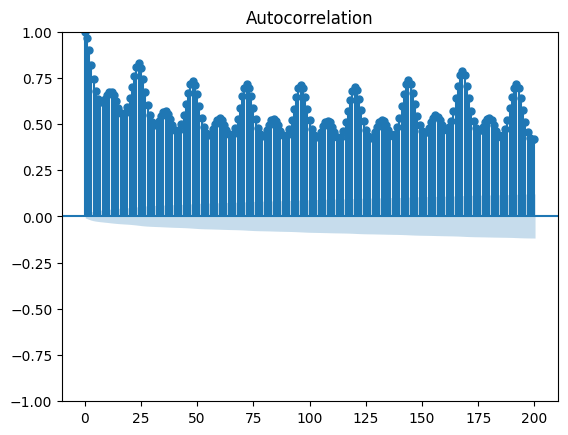

In [36]:
sm.graphics.tsa.plot_acf(data["price actual"], lags=200);

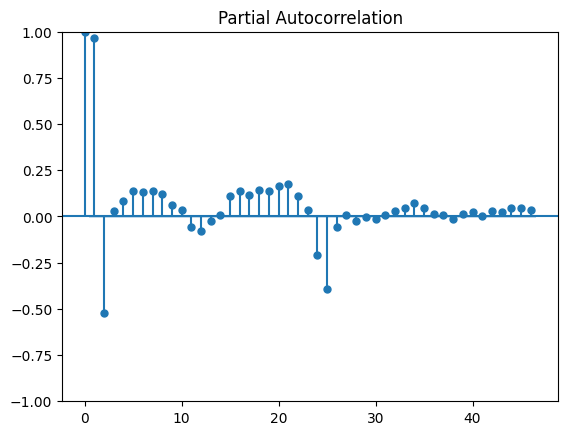

In [46]:
sm.graphics.tsa.plot_pacf(data["price actual"]);

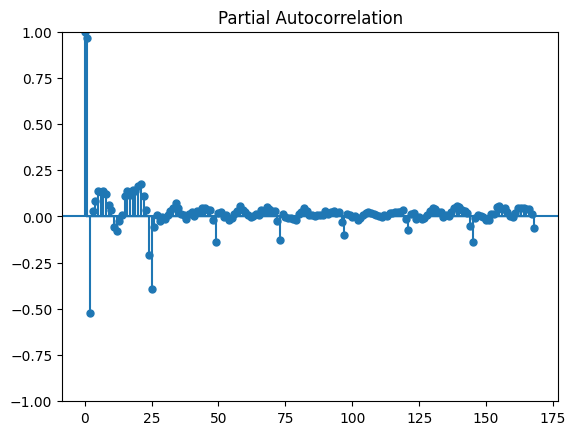

In [54]:
sm.graphics.tsa.plot_pacf(data["price actual"], lags=24*7);

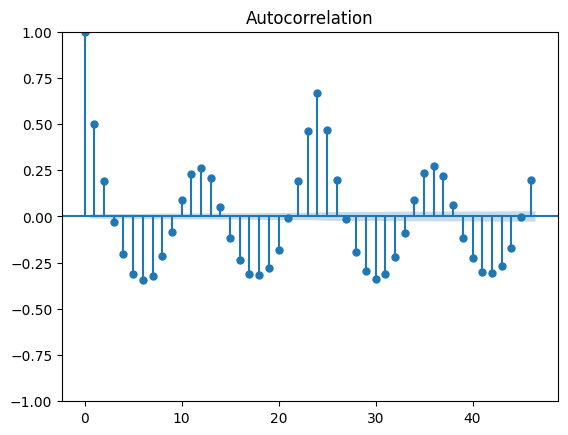

In [51]:
sm.graphics.tsa.plot_acf(data["price actual"].diff().dropna());

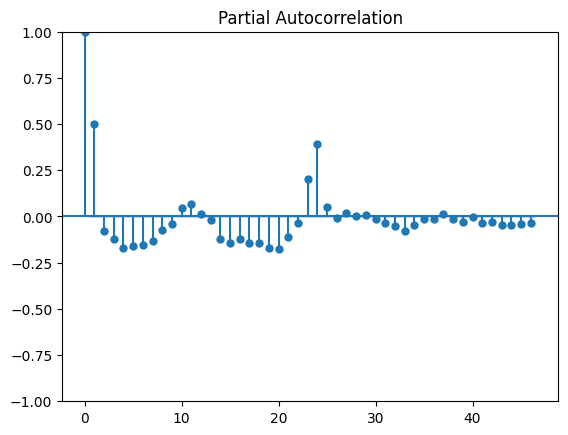

In [52]:
sm.graphics.tsa.plot_pacf(data["price actual"].diff().dropna());

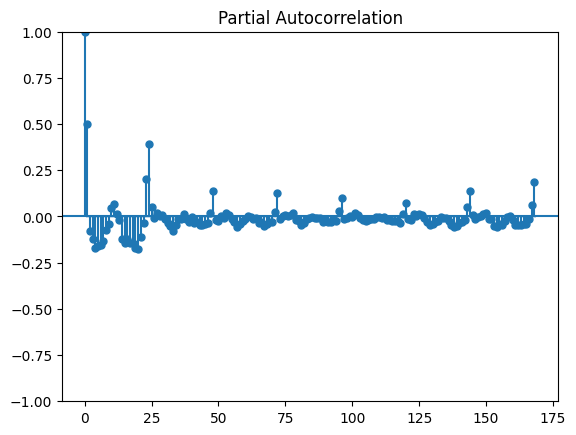

In [53]:
sm.graphics.tsa.plot_pacf(data["price actual"].diff().dropna(), lags=24*7);

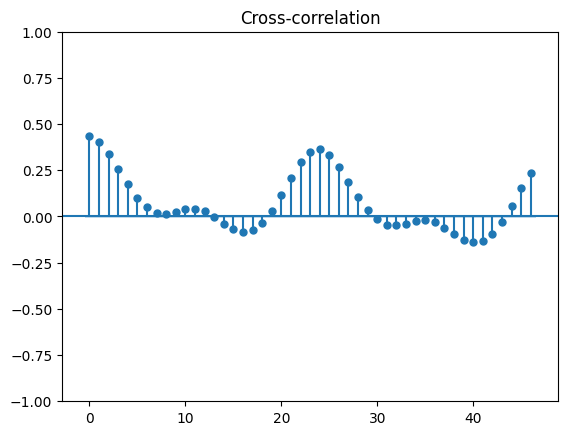

In [47]:
sm.graphics.tsa.plot_ccf(data["price actual"], data["total load actual"].ffill());

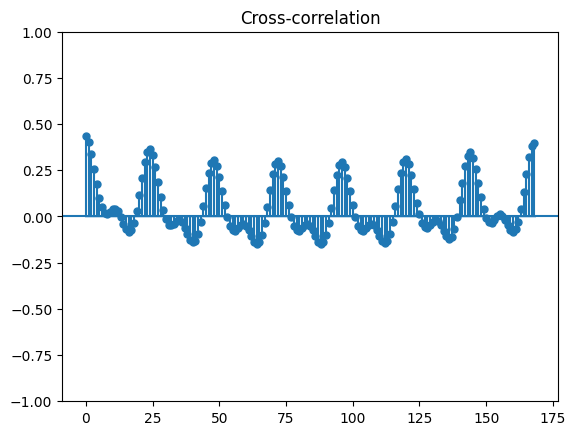

In [50]:
sm.graphics.tsa.plot_ccf(data["price actual"], data["total load actual"].ffill(), lags=24*7);

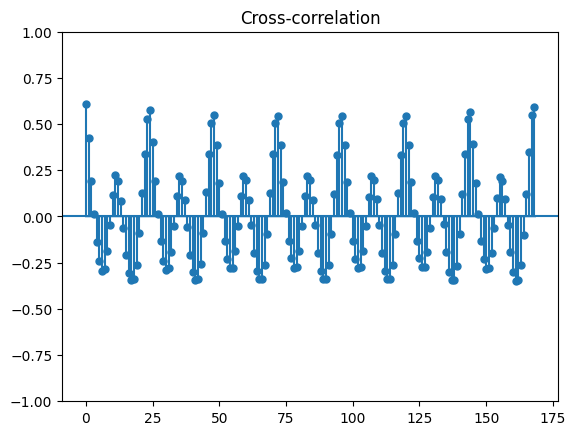

In [60]:
sm.graphics.tsa.plot_ccf(data["price actual"].diff().dropna(), data["total load actual"].ffill().diff().dropna(), lags=24*7);

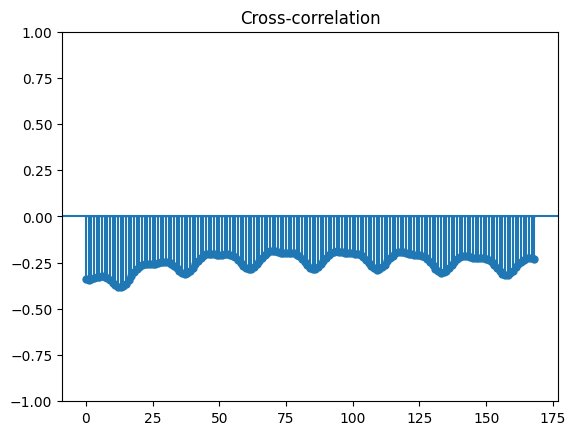

In [55]:
sm.graphics.tsa.plot_ccf(data["price actual"], data["renewables_share"].ffill(), lags=24*7);

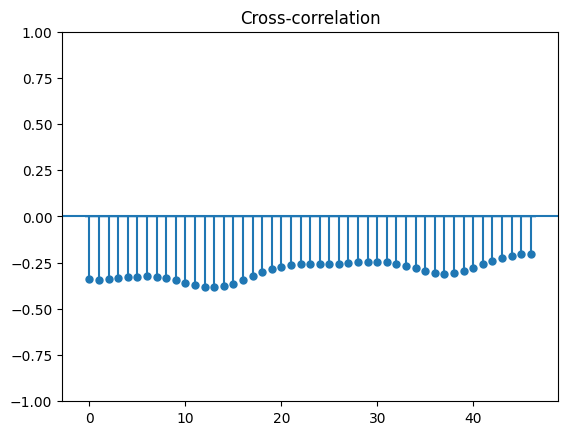

In [56]:
sm.graphics.tsa.plot_ccf(data["price actual"], data["renewables_share"].ffill());

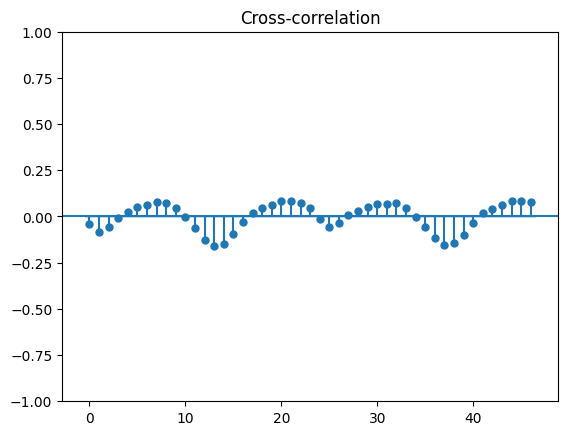

In [61]:
sm.graphics.tsa.plot_ccf(data["price actual"].diff().dropna(), data["renewables_share"].ffill().diff().dropna());

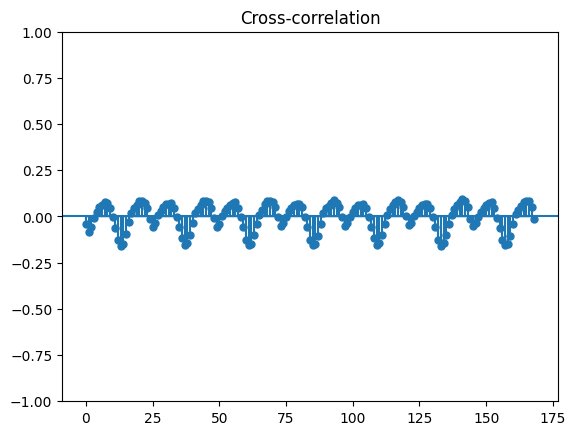

In [62]:
sm.graphics.tsa.plot_ccf(data["price actual"].diff().dropna(), data["renewables_share"].ffill().diff().dropna(), lags=24*7);

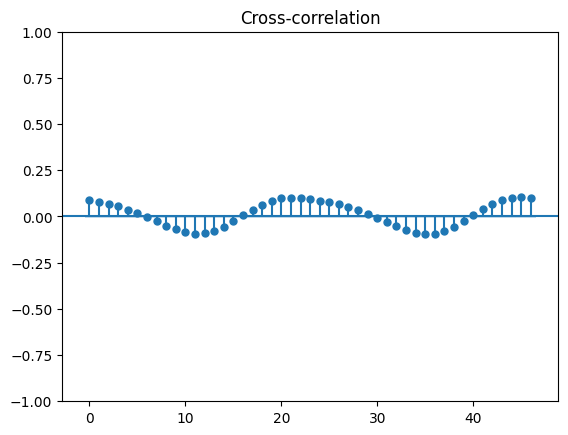

In [58]:
sm.graphics.tsa.plot_ccf(data["price actual"], data["tempMadrid"]);

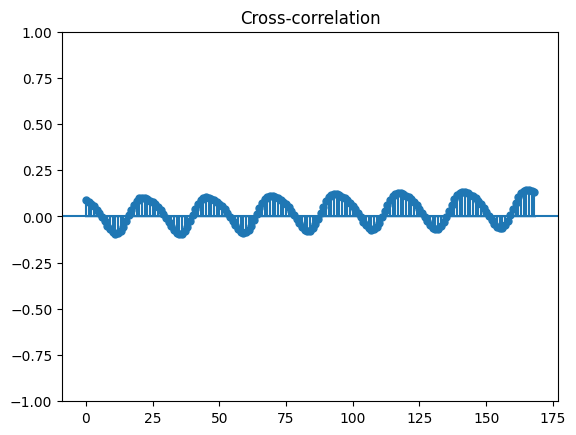

In [59]:
sm.graphics.tsa.plot_ccf(data["price actual"], data["tempMadrid"], lags=24*7);